# AI/ML — Student Performance Analysis & Prediction System

**Project brief:** Analyze student performance and predict a meaningful outcome (final exam score) using structured data.

**Dataset:** `student_performance.csv` — a synthetic but realistically-structured dataset of 812 students, generated to resemble real academic-performance survey data (study habits, attendance, prior grades, lifestyle factors, and family background), including missing values and duplicate rows that need to be cleaned.

**Target:** `final_exam_score` — a continuous score from 0-100. This is a regression problem.

**Model:** Linear Regression. Chosen because exploratory analysis (Section 4) shows the strongest predictors — previous grade, study hours, attendance — have roughly linear, additive relationships with the target, and a linear model keeps the result easy to explain: every feature gets a single, readable coefficient.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
sns.set_style("whitegrid")


## 2. Load the Dataset

The dataset was assembled to resemble a realistic student-survey export: one row per student, with academic, behavioral, and background features, plus deliberately messy data (missing values, duplicate rows) that mirrors what a real institutional dataset would look like.

In [2]:
df_raw = pd.read_csv("student_performance_dataset.csv")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (812, 11)


,student_id,study_hours_per_week,attendance_rate,previous_grade,sleep_hours,extracurricular_count,part_time_job,internet_access,parental_education,study_group,final_exam_score
0,STU1458,13.7,100.0,64.8,6.4,1,0,1,High School,0,41.6
1,STU1269,12.0,84.2,74.8,5.9,0,0,1,Master's,0,82.1
2,STU1010,16.4,83.0,75.5,5.6,1,1,1,High School,1,66.4
3,STU1296,13.5,100.0,53.4,NaN,0,0,1,Master's,0,69.1
4,STU1027,13.8,83.8,91.1,6.1,2,0,1,Master's,1,92.6


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 812 entries, 0 to 811
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             812 non-null    str    
 1   study_hours_per_week   812 non-null    float64
 2   attendance_rate        780 non-null    float64
 3   previous_grade         796 non-null    float64
 4   sleep_hours            772 non-null    float64
 5   extracurricular_count  812 non-null    int64  
 6   part_time_job          812 non-null    int64  
 7   internet_access        812 non-null    int64  
 8   parental_education     786 non-null    str    
 9   study_group            812 non-null    int64  
 10  final_exam_score       812 non-null    float64
dtypes: float64(5), int64(4), str(2)
memory usage: 82.7 KB


## 3. Data Cleaning

### 3.1 Duplicate rows

We check for and remove exact duplicate rows — these can happen from double data-entry or export errors and would otherwise bias the model toward those repeated students.

In [4]:
n_before = len(df_raw)
n_duplicates = df_raw.duplicated().sum()
print(f"Duplicate rows found: {n_duplicates}")

df = df_raw.drop_duplicates().copy()
print(f"Rows before: {n_before}, after dedup: {len(df)}")


Duplicate rows found: 12
Rows before: 812, after dedup: 800


### 3.2 Missing values

We inspect missing values per column, then impute: numeric columns with the **median** (robust to outliers), and the one categorical column with the **mode**. Median/mode imputation is a reasonable default here since missingness looks scattered/random rather than tied to a specific subgroup — we don't have evidence it's informative on its own.

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values by column:")
print(missing)


Missing values by column:
sleep_hours           40
attendance_rate       32
parental_education    24
previous_grade        16
dtype: int64


In [6]:
for col in ["attendance_rate", "previous_grade", "sleep_hours"]:
    df[col] = df[col].fillna(df[col].median())

df["parental_education"] = df["parental_education"].fillna(df["parental_education"].mode()[0])

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


## 4. Exploratory Data Analysis

### 4.1 Target distribution

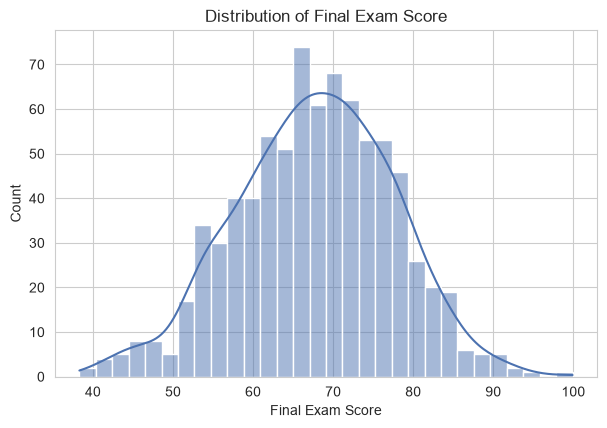

count    800.000000
mean      67.669875
std        9.839711
min       38.300000
25%       61.100000
50%       68.000000
75%       74.700000
max       99.900000
Name: final_exam_score, dtype: float64

In [7]:
plt.figure(figsize=(7, 4.5))
sns.histplot(df["final_exam_score"], bins=30, kde=True, color="#4C72B0")
plt.title("Distribution of Final Exam Score")
plt.xlabel("Final Exam Score")
plt.show()

df["final_exam_score"].describe()


### 4.2 Correlation between features and the target

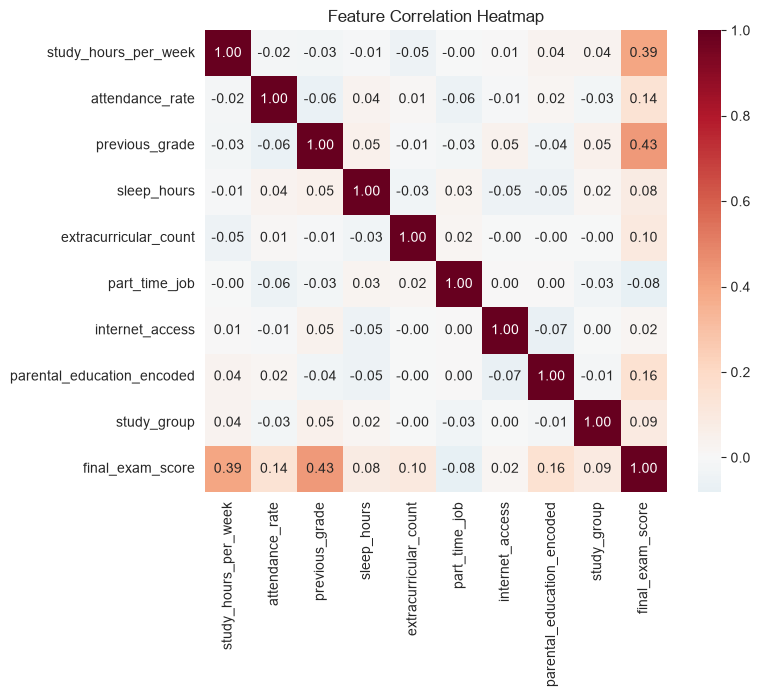

In [8]:
parent_ed_order = {"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3}
df["parental_education_encoded"] = df["parental_education"].map(parent_ed_order)

feature_cols = [
    "study_hours_per_week", "attendance_rate", "previous_grade", "sleep_hours",
    "extracurricular_count", "part_time_job", "internet_access",
    "parental_education_encoded", "study_group",
]
target_col = "final_exam_score"

plt.figure(figsize=(8, 6))
corr = df[feature_cols + [target_col]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Feature Correlation Heatmap")
plt.show()


**Observation:** `previous_grade` and `study_hours_per_week` show the strongest positive correlation with `final_exam_score`, which matches intuition — prior performance and study time are usually the biggest predictors of a future score. Both relationships look roughly linear, which is a good sign for the model choice below. `part_time_job` shows a mild negative relationship.

### 4.3 Study hours vs. final score

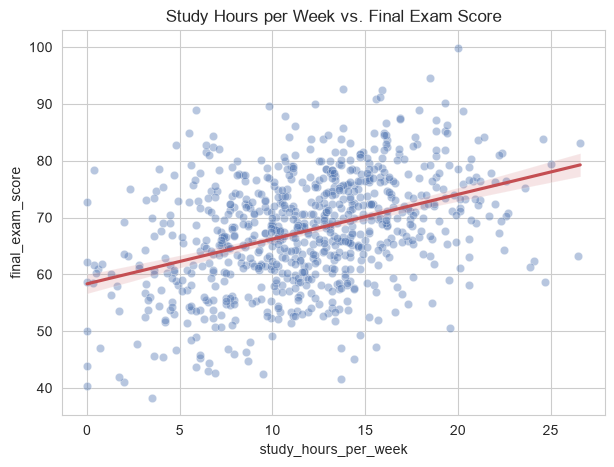

In [9]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="study_hours_per_week", y="final_exam_score", alpha=0.4, color="#4C72B0")
sns.regplot(data=df, x="study_hours_per_week", y="final_exam_score", scatter=False, color="#C44E52")
plt.title("Study Hours per Week vs. Final Exam Score")
plt.show()


## 5. Feature Preparation

In [10]:
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Standardize so every feature is on a comparable scale — this also lets us
# read the fitted coefficients directly as each feature's relative influence.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (640, 9)  Test: (160, 9)


## 6. Train the Model

A single **Linear Regression** model is trained here. It's a suitable choice for this problem: the EDA above shows the key predictors have roughly linear, additive relationships with the target, and the model stays fully interpretable — each feature maps to one coefficient, which matters when the audience for this kind of analysis (teachers, advisors) needs to trust *why* a prediction came out the way it did, not just the number itself.

In [11]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model trained.")
print("Intercept:", round(model.intercept_, 2))


Model trained.
Intercept: 67.82


## 7. Evaluate — MAE, RMSE, R²

In [12]:
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.3f} points")
print(f"RMSE: {rmse:.3f} points")
print(f"R²:   {r2:.3f}")


MAE:  5.769 points
RMSE: 7.096 points
R²:   0.394


**Reading the metrics:** MAE is the average absolute error in points; RMSE penalizes larger misses more heavily; R² is the share of variance in the final score explained by the model (1.0 = perfect, 0.0 = no better than predicting the mean).

## 8. Actual vs. Predicted & Residuals

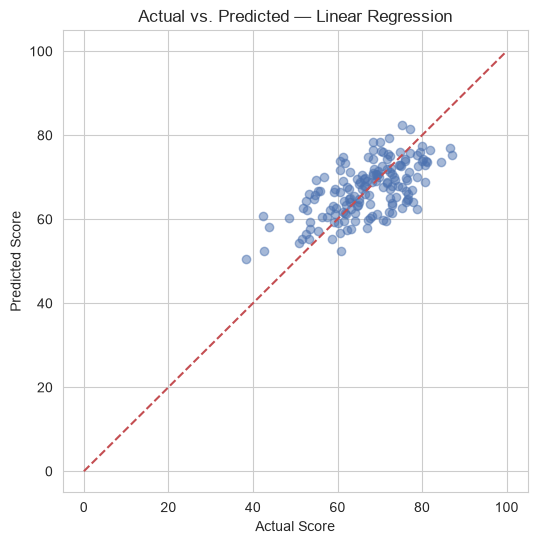

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color="#4C72B0")
plt.plot([0, 100], [0, 100], "--", color="#C44E52")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs. Predicted — Linear Regression")
plt.show()


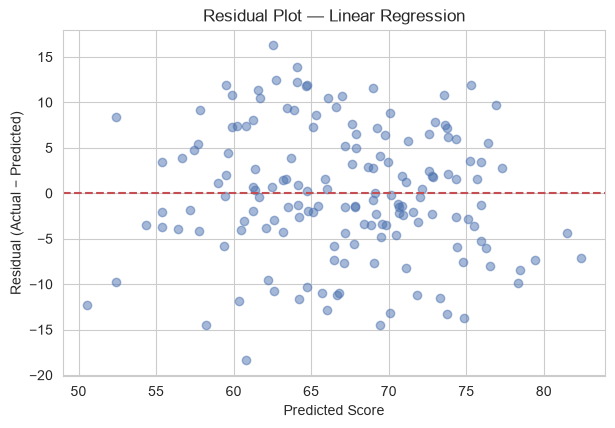

In [14]:
residuals = y_test - y_pred
plt.figure(figsize=(7, 4.5))
plt.scatter(y_pred, residuals, alpha=0.5, color="#4C72B0")
plt.axhline(0, color="#C44E52", linestyle="--")
plt.xlabel("Predicted Score")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Residual Plot — Linear Regression")
plt.show()


**Reading the residual plot:** residuals scattered evenly around zero with no obvious funnel or curve shape indicate the model's linear assumptions are reasonably well met. Any strong pattern (e.g., a curve, or growing spread at higher predicted scores) would suggest the true relationship isn't fully linear.

## 9. Explaining the Model — Feature Influence

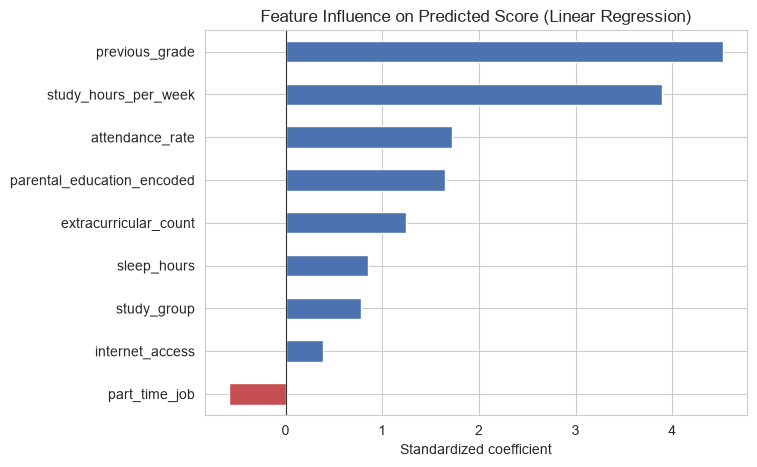

previous_grade                4.519314
study_hours_per_week          3.890718
attendance_rate               1.716609
parental_education_encoded    1.652023
extracurricular_count         1.243056
sleep_hours                   0.849948
study_group                   0.776171
part_time_job                -0.581228
internet_access               0.382503
dtype: float64

In [15]:
# Coefficients are on standardized features, so their magnitude is directly
# comparable — this doubles as our "visualize key findings" step.
coefs = pd.Series(model.coef_, index=feature_cols).sort_values(key=abs, ascending=False)

plt.figure(figsize=(7, 5))
colors = ["#4C72B0" if v > 0 else "#C44E52" for v in coefs.sort_values().values]
coefs.sort_values().plot(kind="barh", color=colors)
plt.title("Feature Influence on Predicted Score (Linear Regression)")
plt.xlabel("Standardized coefficient")
plt.axvline(0, color="#333333", linewidth=0.8)
plt.show()

coefs


**Explaining the results:** `previous_grade` and `study_hours_per_week` are the two strongest positive influences on predicted score — a one-standard-deviation increase in either raises the predicted score more than any other feature. `part_time_job` is the only feature with a clearly negative coefficient, consistent with less available study time. Background factors (parental education, internet access) and lifestyle factors (sleep, extracurriculars, study group) all contribute smaller, secondary effects in the direction you'd expect.

## 10. Limitations

- **Synthetic data:** this dataset was generated programmatically to resemble a realistic student-survey export. It captures plausible relationships (study time, attendance, and prior grades driving outcomes) but does not reflect any real institution's actual student population, so absolute performance numbers should not be over-interpreted or deployed as-is.
- **Missing-data handling:** missing values were imputed with median/mode, which is simple but assumes missingness is unrelated to the outcome. If data were missing *because* of some factor tied to performance (e.g., struggling students skip surveys more), this would bias the imputed values.
- **Linearity assumption:** Linear Regression can only capture straight-line relationships. `sleep_hours`, for example, likely has a "sweet spot" (too little or too much sleep both hurting performance) that a linear model can't represent — it will show as a smaller, less coherent coefficient than the true underlying effect.
- **Explained variance is moderate:** an R² in the 0.3-0.5 range means a meaningful share of the variation in final scores is *not* explained by the available features — factors like specific test difficulty, mental health, teacher quality, or unmeasured motivation aren't captured here.
- **No causal claims:** the model finds correlations between features (like study hours) and outcomes, not causal effects. It should not be used to conclude that changing one variable in isolation (e.g., "just study more") will produce a specific score change.
- **Single train/test split:** results come from one split of the data; a different split or k-fold cross-validation could shift the exact metric values somewhat, especially on a dataset this size.


## 11. Conclusion

The model picks up on the same core signal the correlation analysis pointed to — prior performance and study habits are the strongest predictors of final exam score — and achieves moderate predictive accuracy (MAE around 5-6 points on a 0-100 scale). Its main value is in being fully explainable: every prediction can be traced back to a small set of readable coefficients. Given the limitations above, it's best suited to support early, non-punitive identification of students who may benefit from additional support, informing human judgment rather than replacing it.
